In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.models.node_pyomo_base_admm import NODEPyomo
from src.models.direct_collocation import BarycentricInterpolation

## 1. Load Bioreactor Dataset (Batch_0, ε = 0.01)

Dimensions of state variable:
- Glucose (G): primary carbon/energy source consumed by cells. 
- Dissolved Oxygen (O): oxygen available for cell metabolism. 
- Viable Cells (X): live, actively growing cell concentration. 
- Dead Cells (Xd): non-viable cell concentration. 
- Product (P): target bioproduct being produced. 
- Lactate (L): metabolic byproduct of glucose consumption. 
- CO2: dissolved carbon dioxide, a metabolic waste product. 

Time grid shape:  (30,)
Y_obs shape:      (30, 7)


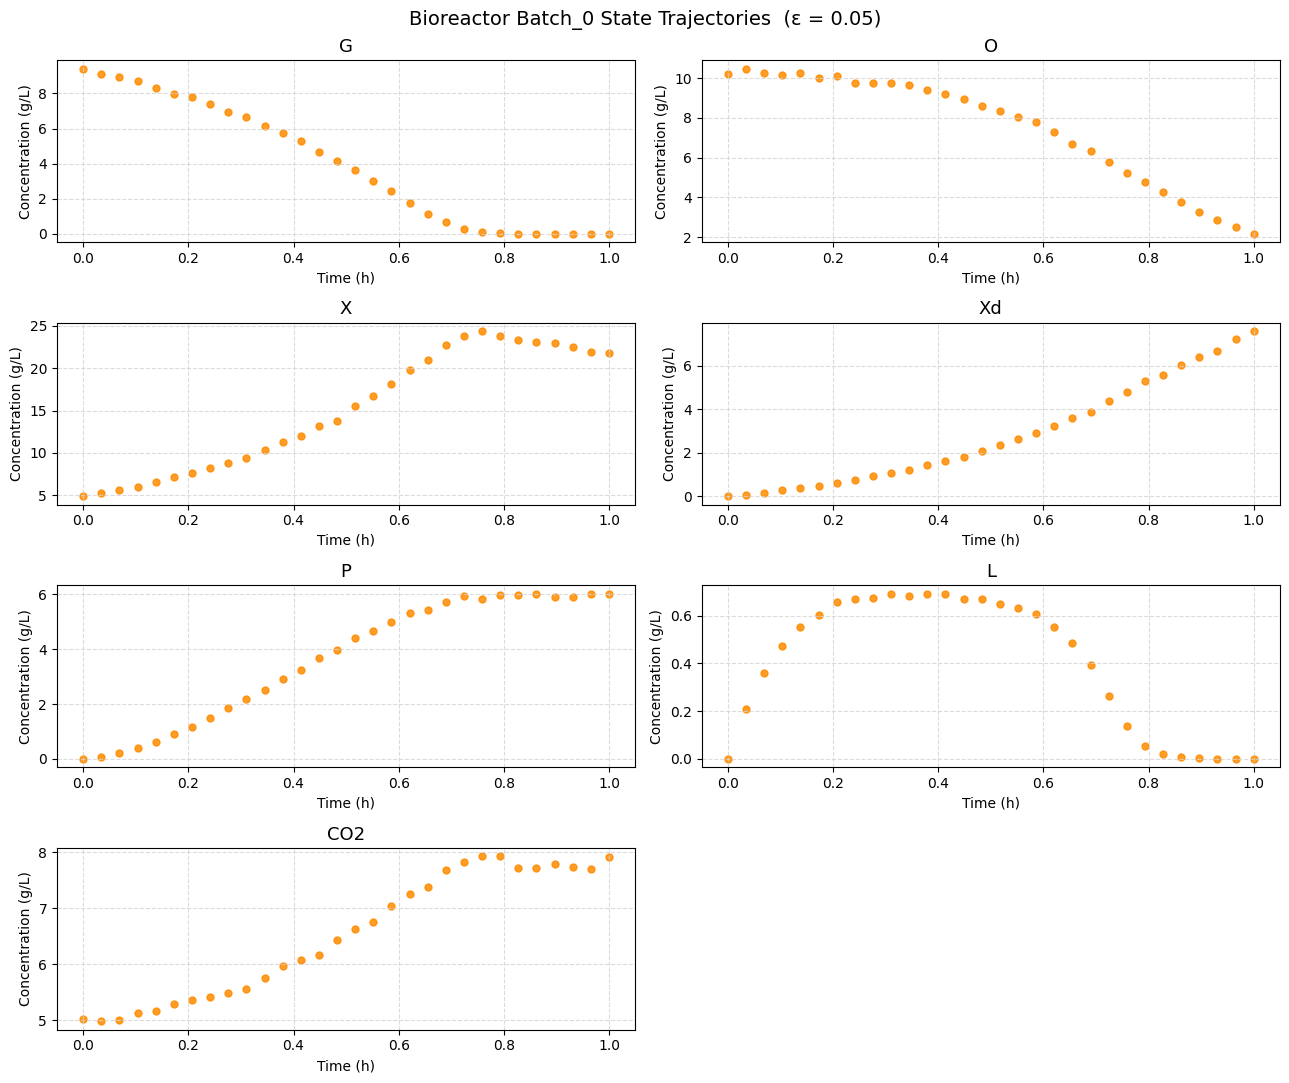

In [2]:
DATA_PATH = "../datasets/bioreactor_sim_by_noise/noise_level_01_eps0.01.csv"
STATE_COLS = ['G', 'O', 'X', 'Xd', 'P', 'L', 'CO2']

df = pd.read_csv(DATA_PATH)
batch_0 = df[df['Batch'] == 'Batch_0'].reset_index(drop=True)

train_grid = batch_0['Time'].values #(30,)
Y_obs = batch_0[STATE_COLS].values #(30, 7)
end_time = float(train_grid[-1])

print(f"Time grid shape:  {train_grid.shape}")
print(f"Y_obs shape:      {Y_obs.shape}")

# Plot all 7 state trajectories
fig, axes = plt.subplots(4, 2, figsize=(13, 11))
axes = axes.flatten()
for i, col in enumerate(STATE_COLS):
    axes[i].scatter(train_grid, Y_obs[:, i], color='darkorange', marker='o', s=25, alpha=0.85)
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('Time (h)')
    axes[i].set_ylabel('Concentration (g/L)')
    axes[i].grid(True, linestyle='--', color='lightgrey', alpha=0.8)
axes[7].set_visible(False)
plt.suptitle("Bioreactor Batch_0 State Trajectories  (ε = 0.05)", fontsize=14)
plt.tight_layout()

## 2. Train Neural ODE model using IPOPT (DC and IRR-DC)

In [ ]:
import time

STATE_DIM = 7

# Architecture sweep space: max hidden width 64, max 2 hidden layers
hidden_widths = [4, 8, 16, 32]
nn_configs = [
    [STATE_DIM, w, STATE_DIM] for w in hidden_widths
] + [
    [STATE_DIM, w, w, STATE_DIM] for w in hidden_widths
]

# Exclude specific architectures from the sweep.
excluded_configs = [
    [STATE_DIM, 32, 32, STATE_DIM]
 ]
nn_configs = [cfg for cfg in nn_configs if cfg not in excluded_configs]

def arch_label(layer_sizes):
    hidden = layer_sizes[1:-1]
    return f"{len(hidden)}H-{ 'x'.join(str(h) for h in hidden) }"

num_res_eval_nodes = 25

solver_options_dc = {
    "max_iter": 500,
    "nlp_scaling_method": "gradient-based",
    "mu_strategy": "adaptive",
    "tol": 1e-6,
    "acceptable_tol": 1e-5,
    "acceptable_iter": 10
}

# Baseline DC model
baseline_layer_sizes = [STATE_DIM, 32, STATE_DIM]
pyo_model_dc = NODEPyomo(
    Y_obs, baseline_layer_sizes, end_time,
    state_lower_bound=-1000,
    state_upper_bound=1000,
    param_lower_bound=-100,
    param_upper_bound=100,
    lambda_reg=1e-4,
    transcription_method='dc'
 )
pyo_model_dc.solve_model(solver_options_dc)

# DC sweep (moved from former Section 2b)
sweep_results = {}  # architecture label -> model/prediction metadata

y0 = Y_obs[0, :]
dt = float(train_grid[1] - train_grid[0])

for ls in nn_configs:
    label = arch_label(ls)
    print(f"\n{'='*60}")
    print(f"Architecture: {label} | layer_sizes={ls}")
    print(f"{'='*60}")

    t0 = time.perf_counter()
    model = NODEPyomo(
        Y_obs, ls, end_time,
        state_lower_bound=-1000,
        state_upper_bound=1000,
        param_lower_bound=-100,
        param_upper_bound=100,
        lambda_reg=1e-4,
        transcription_method='dc',
    )
    model.solve_model(solver_options_dc)
    solve_time = time.perf_counter() - t0

    solve_info = getattr(model, 'last_solve_info', {})
    iterations = solve_info.get('iterations')

    try:
        predicted = model.get_predicted_trajectory(
            y0, train_grid, rtol=1e-7, atol=1e-9, max_step=dt
        )
        status = 'ok'
    except Exception as e:
        predicted = None
        status = f'integration failed: {e}'

    sweep_results[label] = {
        'layer_sizes': ls,
        'model': model,
        'predicted': predicted,
        'solve_time': solve_time,
        'iterations': iterations,
        'solver_status': solve_info.get('status'),
        'termination_condition': solve_info.get('termination_condition'),
        'status': status,
    }
    print(f"  Solve time: {solve_time:.1f}s | Iterations: {iterations} | Integration: {status}")

num_success = sum(1 for r in sweep_results.values() if r['predicted'] is not None)
print(f"\nSweep complete. {num_success}/{len(nn_configs)} architectures integrated successfully.")

Solver available?: True
Ipopt 3.14.19: max_iter=500
nlp_scaling_method=gradient-based
mu_strategy=adaptive
print_level=5
tol=1e-06
acceptable_tol=1e-05
acceptable_iter=10


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    65982
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   101434

Total number of variables............................:      697
                     variables with only lower bounds:        0
                variables with lower and upper b

In [ ]:
solver_options_irrdc = {
    "max_iter": 1000,
    "nlp_scaling_method": "gradient-based",
    "mu_strategy": "adaptive",
    "tol": 1e-6,
    "acceptable_tol": 1e-5,
    "acceptable_iter": 10
}

# Requested IRR-DC sweep architectures
irrdc_configs = [
    [7, 4, 7],
    [7, 8, 7],
    [7, 16, 7],
    [7, 32, 7],
]

irrdc_sweep_results = {}

y0 = Y_obs[0, :]
dt = float(train_grid[1] - train_grid[0])

for ls in irrdc_configs:
    label = arch_label(ls)
    print(f"\n{'='*60}")
    print(f"IRR-DC architecture: {label} | layer_sizes={ls}")
    print(f"{'='*60}")

    t0 = time.perf_counter()
    model = NODEPyomo(
        Y_obs, ls, end_time,
        state_lower_bound=-1000,
        state_upper_bound=1000,
        param_lower_bound=-100,
        param_upper_bound=100,
        lambda_reg=1e-4,
        transcription_method='irrdc',
        rho_reg=5,
        num_res_eval_nodes=num_res_eval_nodes
    )
    model.solve_model(solver_options_irrdc)
    solve_time = time.perf_counter() - t0

    solve_info = getattr(model, 'last_solve_info', {})
    iterations = solve_info.get('iterations')

    try:
        predicted = model.get_predicted_trajectory(
            y0, train_grid, rtol=1e-7, atol=1e-9, max_step=dt
        )
        status = 'ok'
    except Exception as e:
        predicted = None
        status = f'integration failed: {e}'

    irrdc_sweep_results[label] = {
        'layer_sizes': ls,
        'model': model,
        'predicted': predicted,
        'solve_time': solve_time,
        'iterations': iterations,
        'solver_status': solve_info.get('status'),
        'termination_condition': solve_info.get('termination_condition'),
        'status': status,
    }
    print(f"  Solve time: {solve_time:.1f}s | Iterations: {iterations} | Integration: {status}")

# Keep one IRR-DC model handle for downstream cells.
pyo_model_irrdc = irrdc_sweep_results[arch_label([7, 32, 7])]['model']
print("\nUsing pyo_model_irrdc = [7, 32, 7] for downstream single-model comparison cells.")


IRR-DC architecture: 1H-4 | layer_sizes=[7, 4, 7]
Number of node clashes between res eval grid and colloc grid: 2 of 25 res eval nodes.
Solver available?: True
Ipopt 3.14.19: max_iter=1000
nlp_scaling_method=gradient-based
mu_strategy=adaptive
print_level=5
tol=1e-06
acceptable_tol=1e-05
acceptable_iter=10


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:    14826
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    37978

Total number of variables.............

Training runtime and IPOPT iteration summary (DC + IRR-DC sweeps)

In [8]:
rows = []

for _, res in sweep_results.items():
    rows.append({
        'method': 'DC',
        'layer_sizes': res.get('layer_sizes'),
        'solve_time_s': res.get('solve_time'),
    })

for _, res in irrdc_sweep_results.items():
    rows.append({
        'method': 'IRR-DC',
        'layer_sizes': res.get('layer_sizes'),
        'solve_time_s': res.get('solve_time'),
    })

runtime_df = pd.DataFrame(rows, columns=['method', 'layer_sizes', 'solve_time_s'])

if not runtime_df.empty:
    # Approximate model size by total trainable parameters for the given architecture.
    def count_params(layer_sizes):
        if not isinstance(layer_sizes, (list, tuple)) or len(layer_sizes) < 2:
            return float('inf')
        return sum(
            layer_sizes[i] * layer_sizes[i + 1] + layer_sizes[i + 1]
            for i in range(len(layer_sizes) - 1)
        )

    runtime_df['model_size'] = runtime_df['layer_sizes'].map(count_params)
    runtime_df['layer_sizes_str'] = runtime_df['layer_sizes'].map(
        lambda x: str(x) if isinstance(x, (list, tuple)) else 'n/a'
    )

    method_order = {'DC': 0, 'IRR-DC': 1}
    runtime_df['method_order'] = runtime_df['method'].map(lambda m: method_order.get(m, 99))

    runtime_df = runtime_df.sort_values(
        ['model_size', 'layer_sizes_str', 'method_order']
    ).reset_index(drop=True)

    runtime_df['solve_time_s'] = runtime_df['solve_time_s'].map(
        lambda x: f"{float(x):.2f}" if pd.notnull(x) else 'n/a'
    )

    runtime_df = runtime_df[['method', 'layer_sizes_str', 'solve_time_s']]
    runtime_df = runtime_df.rename(columns={'layer_sizes_str': 'layer_sizes'})

display(runtime_df)

,method,layer_sizes,solve_time_s
0,DC,"[7, 4, 7]",2.92
1,IRR-DC,"[7, 4, 7]",11.16
2,DC,"[7, 4, 4, 7]",12.71
3,DC,"[7, 8, 7]",3.87
4,IRR-DC,"[7, 8, 7]",20.29
5,DC,"[7, 8, 8, 7]",29.50
6,DC,"[7, 16, 7]",4.92
7,IRR-DC,"[7, 16, 7]",121.51
8,DC,"[7, 32, 7]",13.36
9,IRR-DC,"[7, 32, 7]",387.78


## 3. Forward-integrate the trained models over the training domain

In [9]:
y0 = Y_obs[0, :] # initial condition from Batch_0
dt = float(train_grid[1] - train_grid[0]) # equidistant step size

predicted_train_dc = pyo_model_dc.get_predicted_trajectory(
    y0, train_grid, rtol=1e-7, atol=1e-9, max_step=dt
)
predicted_train_irrdc = pyo_model_irrdc.get_predicted_trajectory(
    y0, train_grid, rtol=1e-7, atol=1e-9, max_step=dt
)

print(f"DC predicted trajectory shape: {predicted_train_dc.shape}")
print(f"IRRDC predicted trajectory shape: {predicted_train_irrdc.shape}")

DC predicted trajectory shape: (30, 7)
IRRDC predicted trajectory shape: (30, 7)


## 4. Plot predicted vs observed trajectories (DC + IRR-DC sweeps)

Common layer sizes in DC and IRR-DC sweeps: ['1H-4', '1H-8', '1H-16', '1H-32']
2-hidden-layer DC runs: ['2H-4x4', '2H-8x8', '2H-16x16']
Largest-hidden-layer IRR-DC run: 1H-32


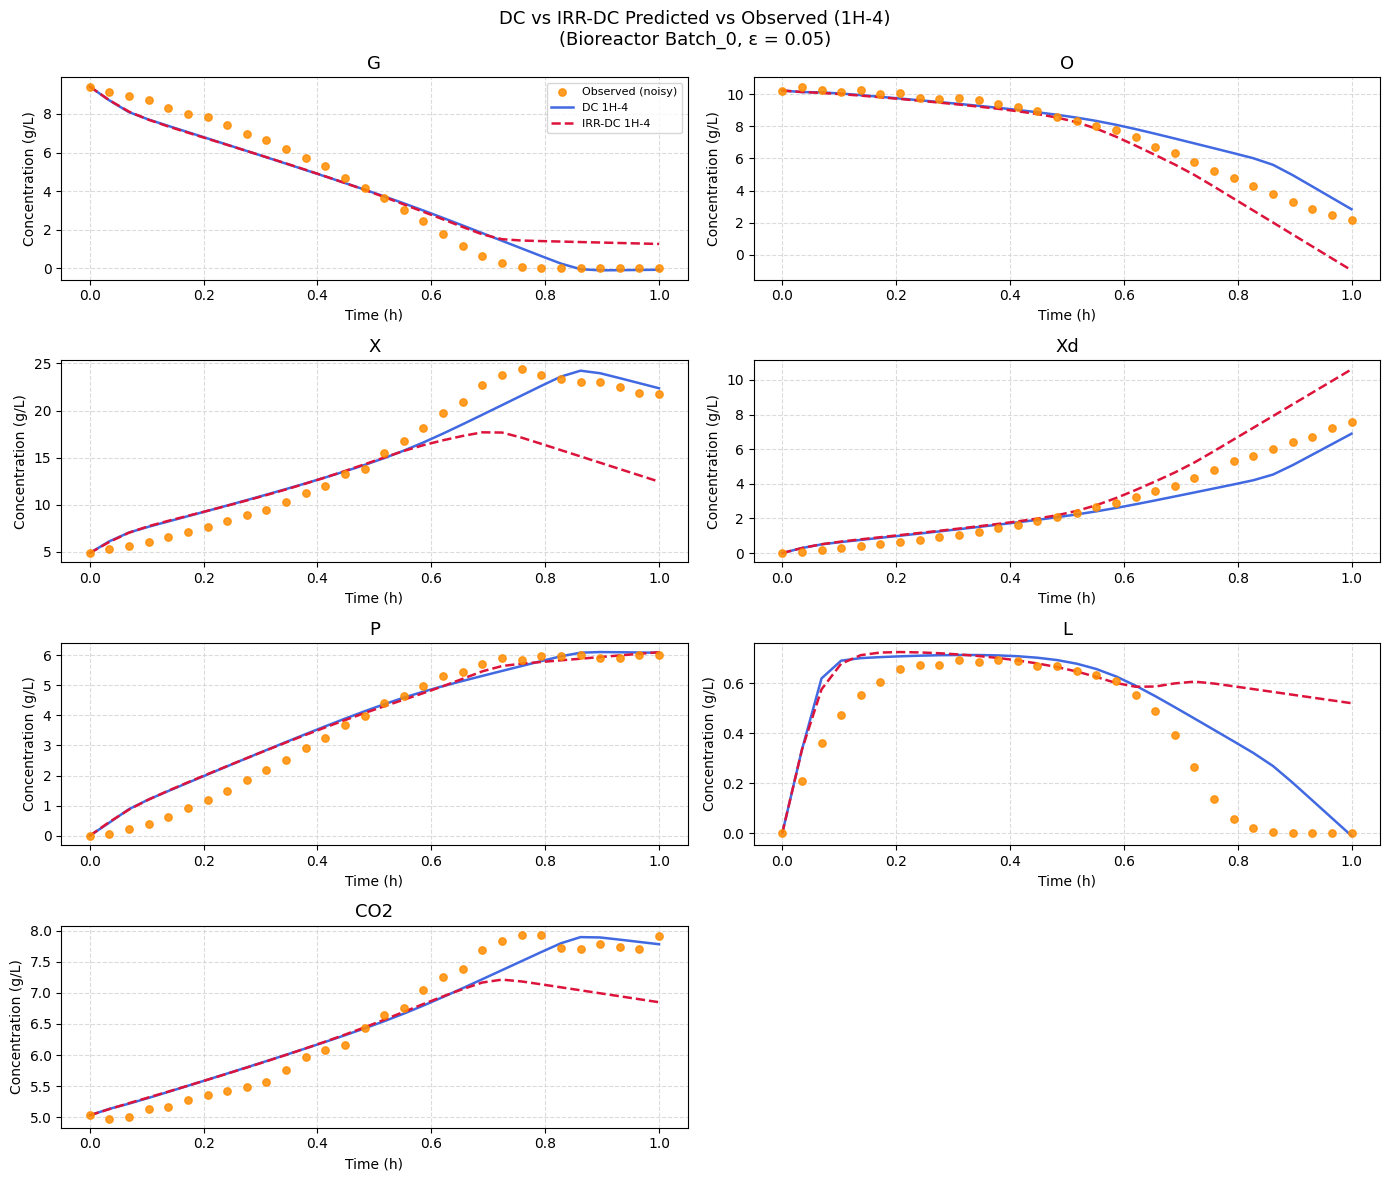

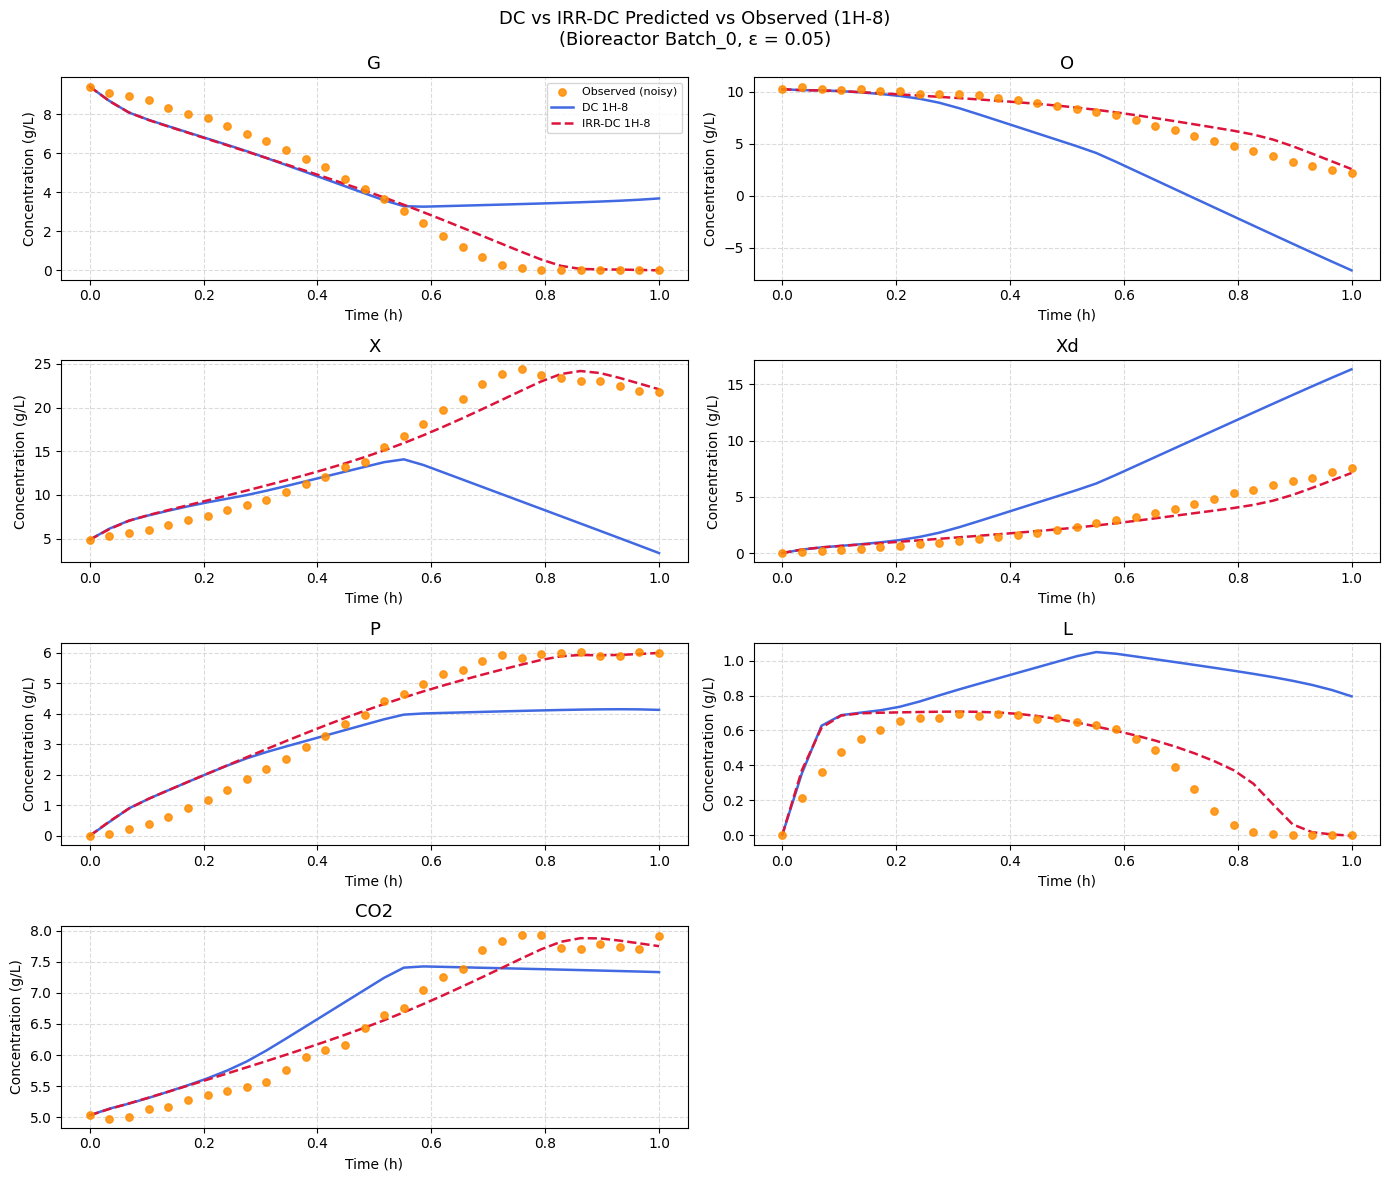

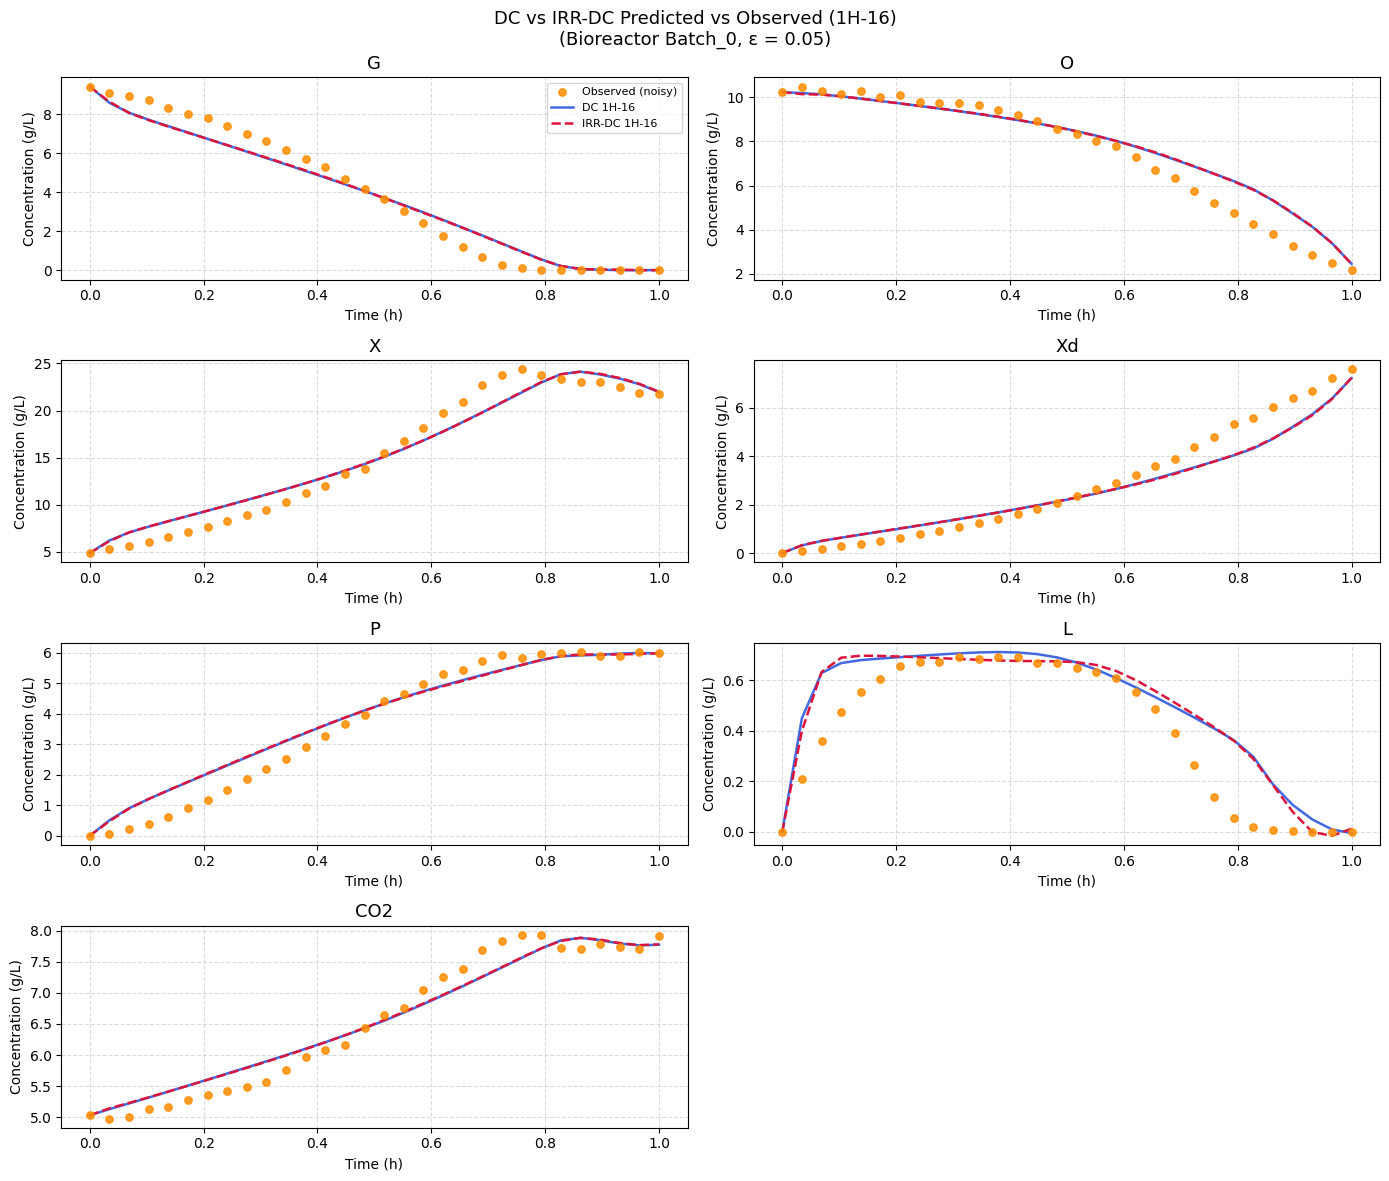

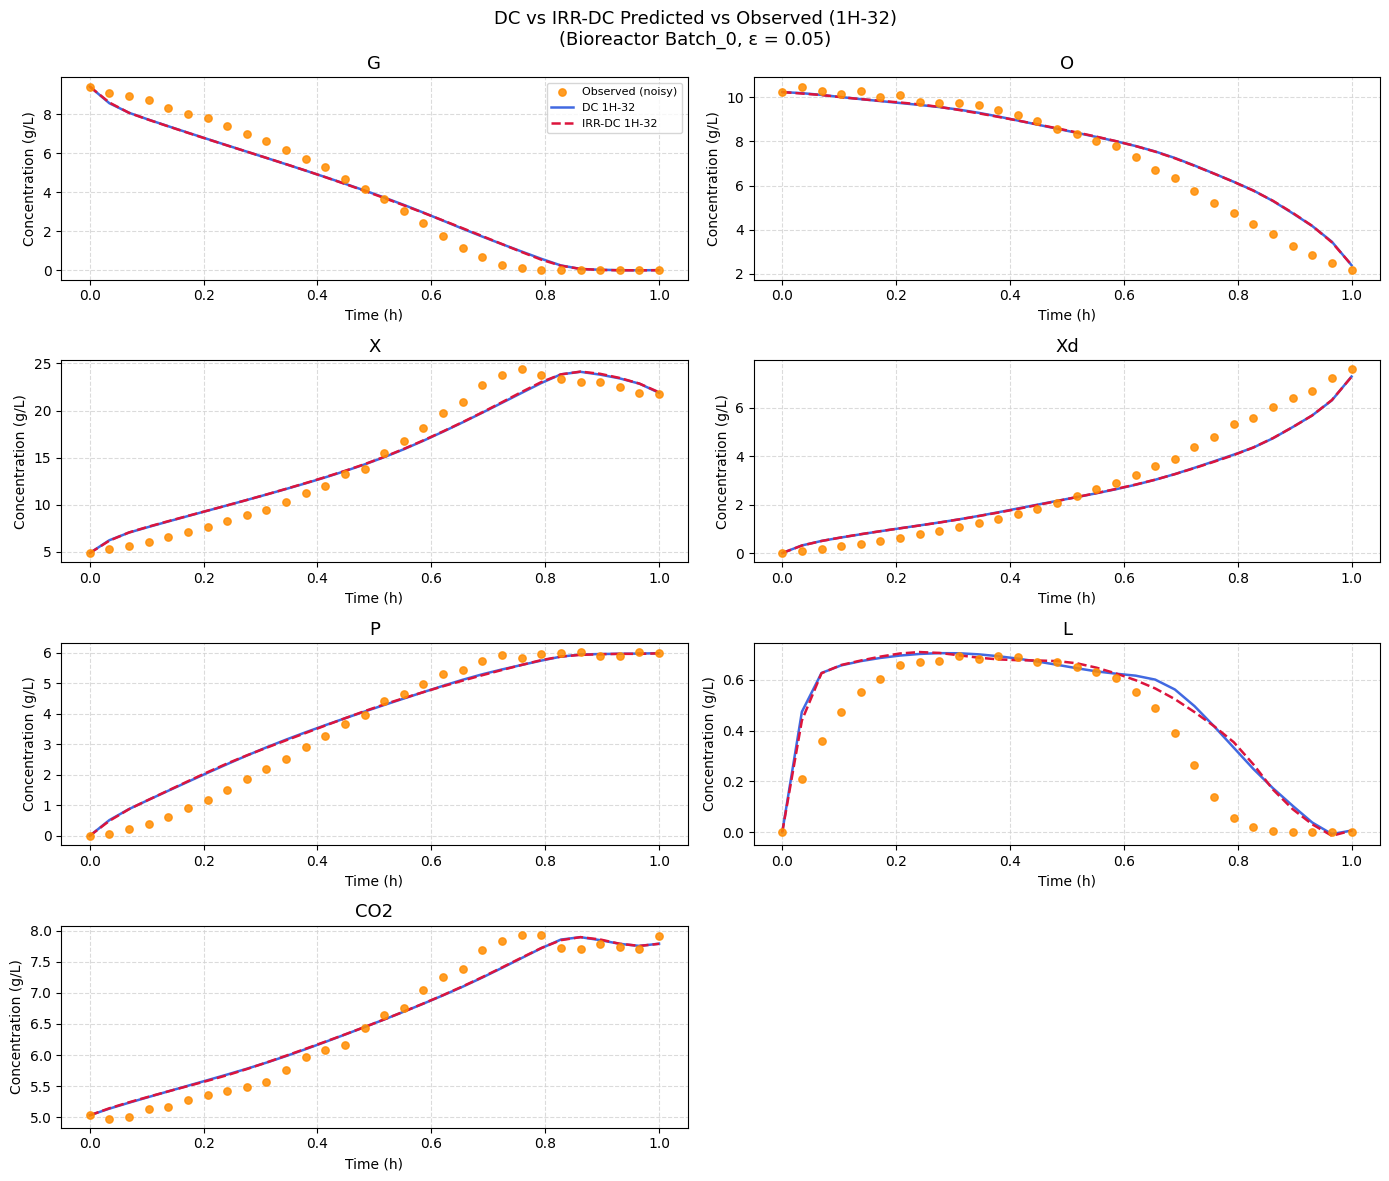

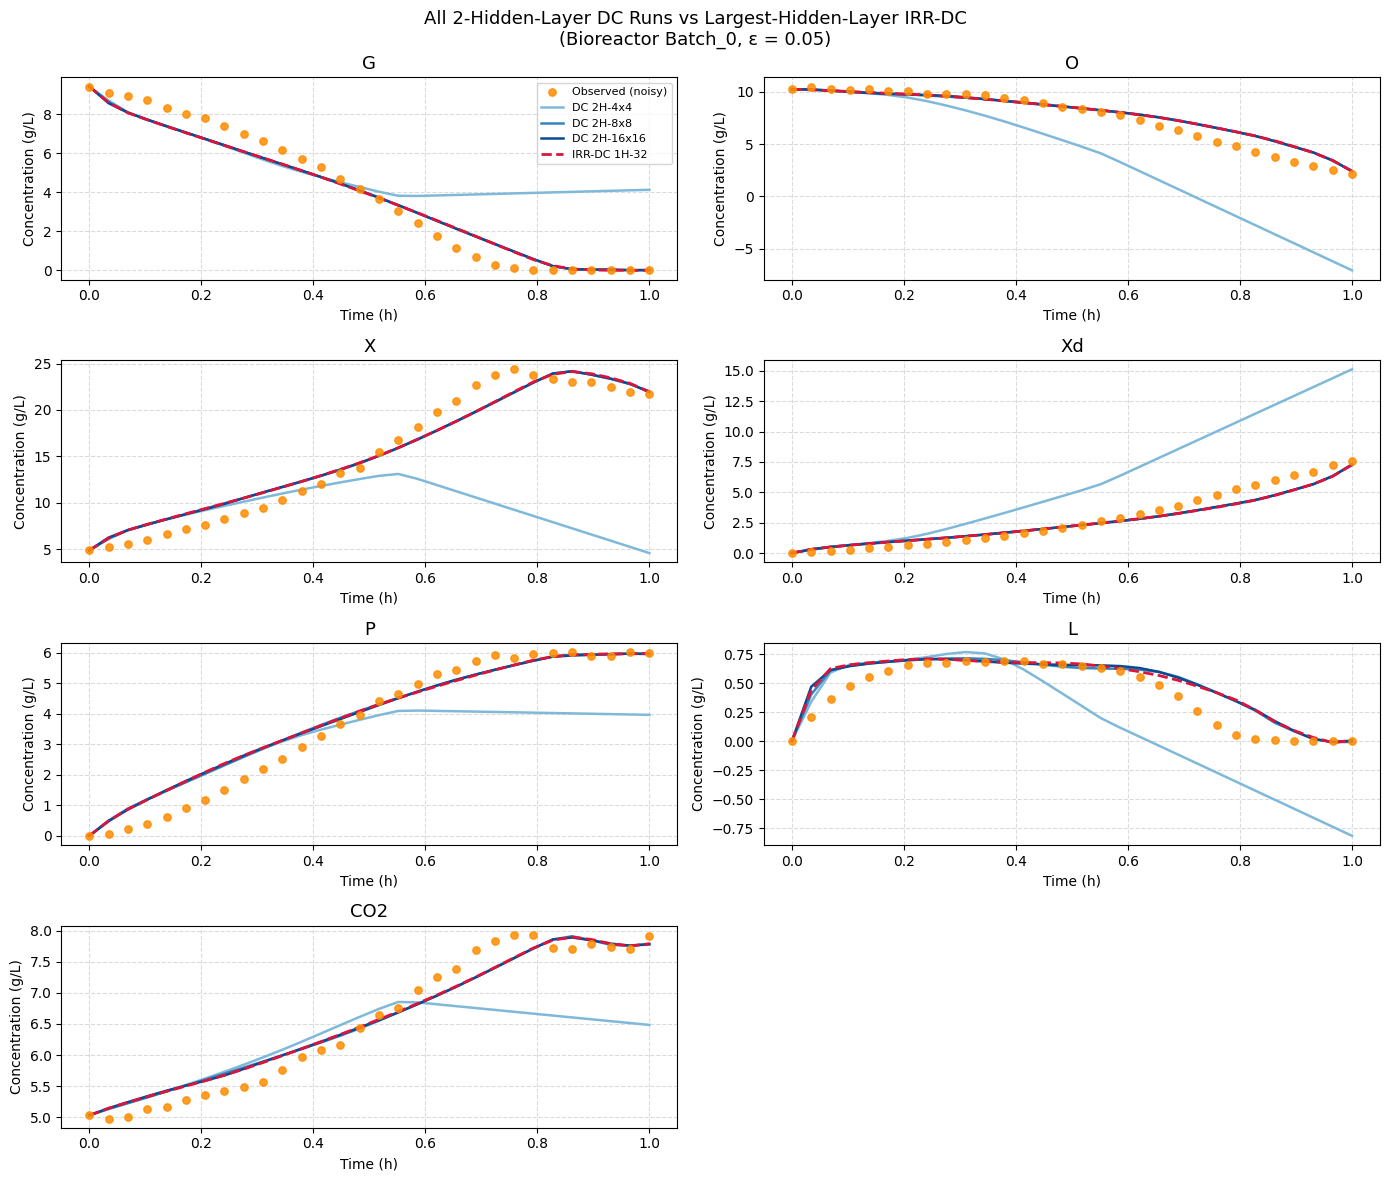

In [10]:
dc_labels = list(sweep_results.keys())
irrdc_labels = list(irrdc_sweep_results.keys())

# Plot only layer sizes that exist in both sweeps.
common_labels = [label for label in dc_labels if label in irrdc_labels]
print(f"Common layer sizes in DC and IRR-DC sweeps: {common_labels}")

for arch in common_labels:
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()

    dc_pred = sweep_results[arch]['predicted']
    irrdc_pred = irrdc_sweep_results[arch]['predicted']

    for i, col in enumerate(STATE_COLS):
        ax = axes[i]
        ax.scatter(
            train_grid, Y_obs[:, i],
            color='darkorange', marker='o', s=28, alpha=0.85,
            label='Observed (noisy)', zorder=5
        )

        if dc_pred is not None:
            ax.plot(
                train_grid, dc_pred[:, i],
                color='royalblue', linewidth=1.8, linestyle='-',
                label=f'DC {arch}'
            )

        if irrdc_pred is not None:
            ax.plot(
                train_grid, irrdc_pred[:, i],
                color='crimson', linewidth=1.8, linestyle='--',
                label=f'IRR-DC {arch}'
            )

        ax.set_title(col, fontsize=13)
        ax.set_xlabel('Time (h)')
        ax.set_ylabel('Concentration (g/L)')
        ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)
        if i == 0:
            ax.legend(fontsize=8, loc='best')

    axes[7].set_visible(False)
    plt.suptitle(
        f'DC vs IRR-DC Predicted vs Observed ({arch})\n'
        '(Bioreactor Batch_0, ε = 0.05)',
        fontsize=13
    )
    plt.tight_layout()

# Additional comparison: all DC runs with 2 hidden layers vs the largest-hidden-layer IRR-DC run
dc_two_hidden = [
    label for label, res in sweep_results.items()
    if len(res['layer_sizes'][1:-1]) == 2 and res['predicted'] is not None
]

largest_irrdc_label = None
largest_irrdc_pred = None
largest_irrdc_width = -1
for label, res in irrdc_sweep_results.items():
    if res['predicted'] is None:
        continue
    width = max(res['layer_sizes'][1:-1])
    if width > largest_irrdc_width:
        largest_irrdc_width = width
        largest_irrdc_label = label
        largest_irrdc_pred = res['predicted']

print(f"2-hidden-layer DC runs: {dc_two_hidden}")
print(f"Largest-hidden-layer IRR-DC run: {largest_irrdc_label}")

if dc_two_hidden and largest_irrdc_pred is not None:
    dc_cmap = plt.cm.Blues
    dc_colors = [dc_cmap(0.45 + 0.45 * i / max(1, len(dc_two_hidden) - 1)) for i in range(len(dc_two_hidden))]

    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, col in enumerate(STATE_COLS):
        ax = axes[i]
        ax.scatter(
            train_grid, Y_obs[:, i],
            color='darkorange', marker='o', s=28, alpha=0.85,
            label='Observed (noisy)', zorder=5
        )

        for label, color in zip(dc_two_hidden, dc_colors):
            pred = sweep_results[label]['predicted']
            ax.plot(
                train_grid, pred[:, i],
                color=color, linewidth=1.8, linestyle='-',
                label=f'DC {label}'
            )

        ax.plot(
            train_grid, largest_irrdc_pred[:, i],
            color='crimson', linewidth=2.0, linestyle='--',
            label=f'IRR-DC {largest_irrdc_label}'
        )

        ax.set_title(col, fontsize=13)
        ax.set_xlabel('Time (h)')
        ax.set_ylabel('Concentration (g/L)')
        ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)
        if i == 0:
            ax.legend(fontsize=8, loc='best')

    axes[7].set_visible(False)
    plt.suptitle(
        'All 2-Hidden-Layer DC Runs vs Largest-Hidden-Layer IRR-DC\n'
        '(Bioreactor Batch_0, ε = 0.05)',
        fontsize=13
    )
    plt.tight_layout()
else:
    print('Skipping additional plot because required trajectories are unavailable.')

## 5. Plot ODE residual in training domain

Number of node clashes between res eval grid and colloc grid: 2 of 500 res eval nodes.
Number of node clashes between res eval grid and colloc grid: 2 of 500 res eval nodes.


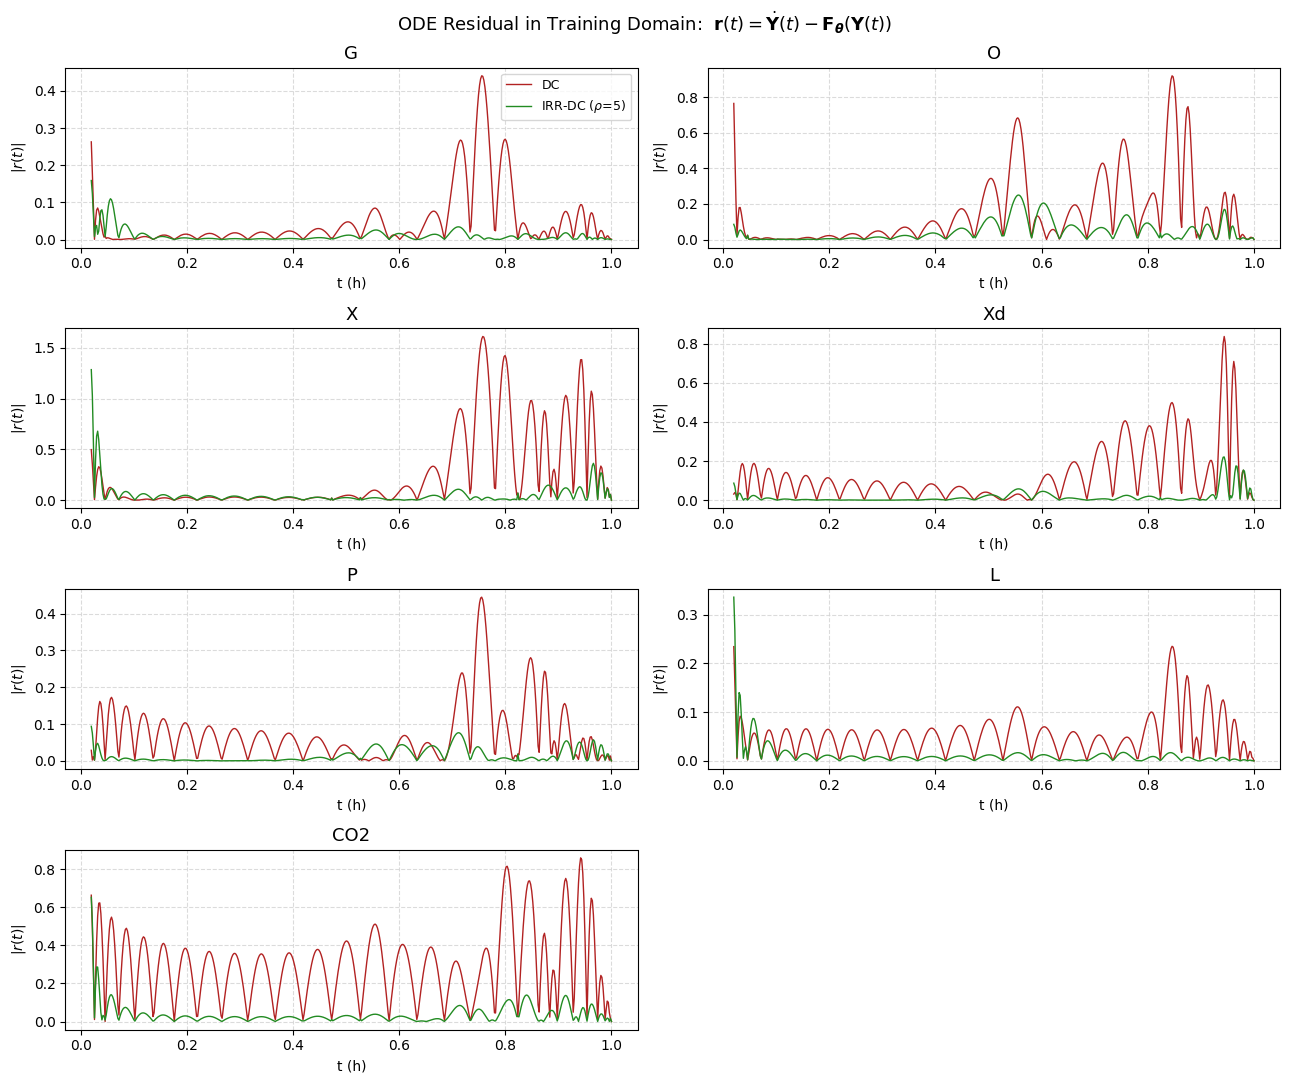

In [ ]:
def compute_continuous_residual(pyo_model, num_eval_nodes):
    """
    Compute r(t) = dY*/dt - NN(Y*(t)) on a dense equidistant grid via
    barycentric interpolation/differentiation of the trained collocation solution.
    Works for both 'dc' and 'irrdc' models.
    Returns: t_eval (num_eval_nodes,), residual (num_eval_nodes, state_dim)
    """
    N = pyo_model.num_colloc_nodes
    bary = BarycentricInterpolation(
        0, pyo_model.end_time, N,
        transcription_method='irrdc',
        num_res_eval_nodes=num_eval_nodes
    )
    L     = bary.L_res                           # (num_eval_nodes, N)
    D     = bary.D_res                           # (num_eval_nodes, N)
    t_eval = bary.res_eval_grid.astype(float)

    Y_star = pyo_model.pyomo_var_to_numpy(
        pyo_model.model.Y_star, (N, pyo_model.state_dim)
    )
    Ws = pyo_model.convert_weights()
    bs = pyo_model.convert_biases()

    ode_lhs = D @ Y_star                         # d(interpolant)/dt at eval nodes
    Y_eval  = L @ Y_star                         # interpolant values at eval nodes
    nn_out  = np.array([
        pyo_model.nn_prediction(0, Y_eval[i], Ws, bs)
        for i in range(num_eval_nodes)
    ])

    return t_eval, ode_lhs - nn_out


num_eval_nodes = 500
skip = 10   # skip boundary points where barycentric interpolation can spike

t_dc,    res_dc    = compute_continuous_residual(pyo_model_dc,    num_eval_nodes)
t_irrdc, res_irrdc = compute_continuous_residual(pyo_model_irrdc, num_eval_nodes)

t_dc     = t_dc[skip:]
res_dc   = res_dc[skip:]
t_irrdc  = t_irrdc[skip:]
res_irrdc = res_irrdc[skip:]

fig, axes = plt.subplots(4, 2, figsize=(13, 11))
axes = axes.flatten()

for i, col in enumerate(STATE_COLS):
    ax = axes[i]
    ax.plot(t_dc,    np.abs(res_dc[:, i]),
            color='firebrick',   linewidth=1.0, label='DC')
    ax.plot(t_irrdc, np.abs(res_irrdc[:, i]),
            color='forestgreen', linewidth=1.0,
            label=fr'IRR-DC ($\rho$={pyo_model_irrdc.rho_reg})')
    ax.set_title(col, fontsize=13)
    ax.set_xlabel('t (h)')
    ax.set_ylabel(r'$|r(t)|$')
    ax.grid(True, linestyle='--', color='lightgrey', alpha=0.8)
    if i == 0:
        ax.legend(fontsize=9)

axes[7].set_visible(False)
plt.suptitle(
    r'ODE Residual in Training Domain:  '
    r'$\mathbf{r}(t) = \dot{\mathbf{Y}}(t) - \mathbf{F}_{\boldsymbol{\theta}}(\mathbf{Y}(t))$',
    fontsize=13
)
plt.tight_layout()